In [23]:
import numpy as np
import pyat.readwrite as at
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [24]:
%reload_ext pyat.readwrite

In [25]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [6]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

NPERSEG = 200

NPEAKS = 20

In [7]:
data1 = scipy.io.loadmat("field_values20260707/field_values20260707.mat")

f = data1['f'].squeeze()
c = data1['soundspeed'].squeeze()
Vg = data1['Vg'][:,:,c == TRUE_SOUNDSPEED,...].squeeze()

In [8]:
df = f[1] - f[0]

t0 = data1['range'][0,0]*1e3/1500
N = SAMPLING_FREQ/df

In [9]:
X = data1["g"][1, data1["soundspeed"]==TRUE_SOUNDSPEED].squeeze()

In [10]:
X = X  * np.exp(1j*2*np.pi*f*t0);
# x = np.real(np.ifft(X,N) * exp(1i*2*pi*(0:N-1)'*f(1)/SAMPLING_FREQ);

x = np.real(np.fft.ifft(X,int(N)) * np.exp(1j*2*np.pi*np.arange(N)*f[0]/SAMPLING_FREQ))

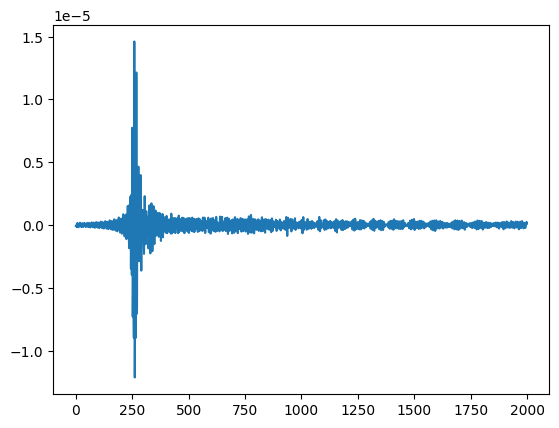

In [11]:
plt.plot(x)

In [12]:
[w, t, X] = sp.spectrogram(x, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG-1, 2000)

w = w[201:502]
X = X[201:502, :]

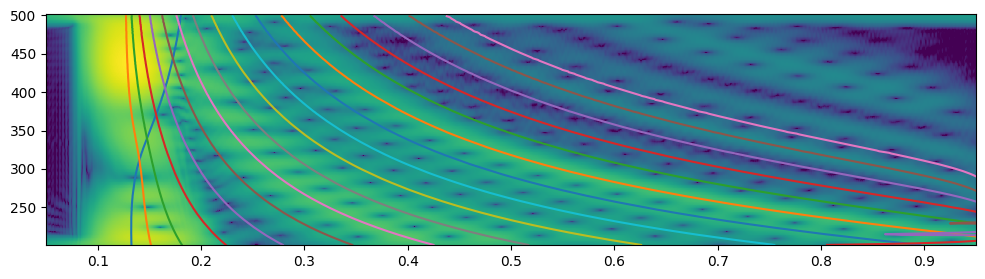

In [13]:
fig, ax = plt.subplots()
[low, high] = np.quantile(10*np.log10(X), [1e-2, 1])

ax.pcolormesh(t, w, 10*np.log10(X), vmin=low, vmax=high)

ax.plot(data1['range'][0,0]*1e3/Vg.T - t0, f[1:-1])
ax.set_xlim(t[[0, -1]])

fig.set_size_inches([12,3])


In [14]:
peaks = list()

# Minimum peak heigh is based on quantile of data
min_height = np.quantile(X, 0.1)

for indf, Xf in enumerate(X):
    # Find peaks and heihgts
    peak_indices, peak_properties = sp.find_peaks(-10*np.log10(Xf), height=min_height)
    # Sort peak indices by height
    sorted_peak_indices = np.argsort(peak_properties['peak_heights'])
    # Grab the times of the NPEAKS tallest peaks
    tnow = t[peak_indices[sorted_peak_indices[-NPEAKS:]]]
    
    peaks.append(np.array([tnow, np.ones(len(tnow))*w[indf]]).T)

peaks = np.concatenate(peaks)

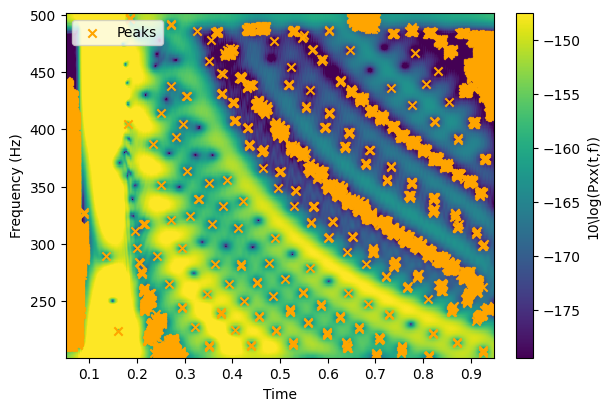

In [15]:
fig, ax = plt.subplots(layout='constrained')
[low, high] = np.quantile(10*np.log10(X), [.1, .9])

m1 = ax.pcolormesh(t, w, 10*np.log10(X), vmin=low, vmax=high)
fig.colorbar(m1, ax=ax, label='10\\log(Pxx(t,f))')
s1 = ax.scatter(peaks[:,0], peaks[:,1], marker='x', c='orange')

ax.set_xlim(t[[0, -1]])

ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')
ax.legend(['Peaks'])

fig.set_size_inches([6,4])

In [16]:
fig.savefig('Spectrogram holes.png', dpi=600)

In [82]:
peaks_mask = peaks[:,0] >= 0.3

peaks_test = peaks[peaks_mask]

In [83]:
base_estimator = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('linear_regression', linear_model.LinearRegression()) ])
reg1 = linear_model.RANSACRegressor(base_estimator, min_samples=100, )
reg1.fit(peaks_test[:,1,np.newaxis], peaks_test[:,0])

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",Pipeline(step...egression())])
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",100
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionad

In [84]:
yy = reg1.predict(f[:,np.newaxis])

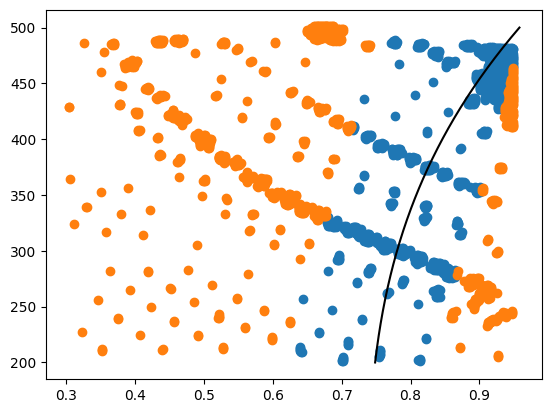

In [85]:
fig, ax = plt.subplots()

ax.scatter(peaks_test[reg1.inlier_mask_,0],peaks_test[reg1.inlier_mask_,1])
ax.scatter(peaks_test[~reg1.inlier_mask_,0],peaks_test[~reg1.inlier_mask_,1])
ax.plot(yy,f, c='k')

In [86]:
fig.savefig("ransac_test.png")